**Product Line Profitability & Margin Performance Analysis for Nassau Candy Distributor**

**Background and Context:**
For distributors like Nassau Candy, sales volume alone is misleading. Some products:

• Sell in high volume but generate low profit
• Consume disproportionate manufacturing or operational cost
• Appear successful but weaken overall margins
To remain competitive, the company must understand:

• Which products truly drive profit
• Which divisions underperform financially
• Where pricing, sourcing, or product rationalization is needed

**Problem Statement**
Currently, the organization lacks visibility into:

• Which product lines deliver the highest gross margin
• Whether high-sales products are actually profitable
• How profitability varies across product divisions
• Which products represent margin risk

**Analytical Methodology (Step-by-Step)**

**Data Cleaning & Validation**

In [1]:
# necessary libraries
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load datset
df = pd.read_csv("/content/drive/My Drive/Nassau Candy Distributor (3).csv")

In [4]:
# view dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [6]:
df.shape

(10194, 18)

In [7]:
# check Duplicate Records
df.duplicated().sum()

np.int64(0)

No duplicate record found.

In [8]:
# Standardize Column Names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

In [9]:
#  Check Missing Values
df.isnull().sum()

,0
row_id,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
country/region,0
city,0
state/province,0
postal_code,0


No missing values found

In [10]:
# 1. Validate Sales Values
df[df['sales']<=0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost


No invalid sales record found.

In [11]:
df = df[df['sales']>0]
print('After Sales filter:', df.shape)

After Sales filter: (10194, 18)


In [12]:
# Validate Cost Values
df[df['cost']<0]


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost


No invalid cost record found.

In [13]:

df = df[df['cost'] >= 0]
print("After cost filter:", df.shape)

After cost filter: (10194, 18)


In [14]:
# 2. Validate Gross profit(Remove Invalid Profit Records)(Gross Profit = Sales - Cost)

df['calculated_profit'] = df['sales'] - df['cost']

In [15]:
df['difference'] = df['gross_profit'] - df['calculated_profit']

In [16]:
np.allclose(df['gross_profit'], df['calculated_profit'])

True

In [17]:
(~np.isclose(df['difference'], 0)).sum()

np.int64(0)

In [18]:
df['difference'] = df['difference'].round(2)

In [19]:
df[df['difference'] != 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,calculated_profit,difference


In [20]:
df.drop(columns=['calculated_profit', 'difference'], inplace=True)

In [21]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country/region,city,state/province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [22]:
# 3.Standardize product and division labels
# Standardize Division labels
df['division'] = (
    df['division']
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .str.title()
)

# Standardize Product Name labels
df['product_name'] = (
    df['product_name']
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .str.title()
)

**Profitability Metric Calculation**

In [23]:
# 1. Gross Margin(%)
# Calculate Gross Margin Percentage
df['gross_margin_%'] = (df['gross_profit'] / df['sales']) * 100

In [24]:
# round the values
df['gross_margin_%'] = df['gross_margin_%'].round(2)

In [25]:
# display the results

df[['product_name', 'sales', 'cost', 'gross_profit', 'gross_margin_%']].head()

,product_name,sales,cost,gross_profit,gross_margin_%
0,Wonka Bar - Milk Chocolate,6.50,2.28,4.22,64.92
1,Wonka Bar - Triple Dazzle Caramel,7.50,2.60,4.90,65.33
2,Wonka Bar - Nutty Crunch Surprise,10.47,3.00,7.47,71.35
3,Wonka Bar -Scrumdiddlyumptious,10.80,3.30,7.50,69.44
4,Wonka Bar - Triple Dazzle Caramel,11.25,3.90,7.35,65.33


In [26]:
# Check the Overall Average Gross Margin
print("Average Gross Margin (%):", round(df['gross_margin_%'].mean(), 2))

Average Gross Margin (%): 66.51


In [27]:
#2. Profit per unit
# Calculate Profit per Unit
df['profit_per_unit'] = df['gross_profit'] / df['units']

In [28]:
# round the values
df['profit_per_unit'] = df['profit_per_unit'].round(2)

In [29]:
# Display the Results
df[['product_name','units','gross_profit','profit_per_unit']].head()

,product_name,units,gross_profit,profit_per_unit
0,Wonka Bar - Milk Chocolate,2,4.22,2.11
1,Wonka Bar - Triple Dazzle Caramel,2,4.90,2.45
2,Wonka Bar - Nutty Crunch Surprise,3,7.47,2.49
3,Wonka Bar -Scrumdiddlyumptious,3,7.50,2.50
4,Wonka Bar - Triple Dazzle Caramel,3,7.35,2.45


In [30]:
# average profit per unit
print("Average Profit per Unit:", round(df['profit_per_unit'].mean(), 2))

Average Profit per Unit: 2.41


In [31]:
# product wise profit per unit
product_profit_unit = (
    df.groupby('product_name')
      .agg(
          Total_Units=('units', 'sum'),
          Total_Gross_Profit=('gross_profit', 'sum'),
          Average_Profit_Per_Unit=('profit_per_unit', 'mean')
      )
      .round(2)
      .sort_values(by='Average_Profit_Per_Unit', ascending=False)
)

product_profit_unit

,Total_Units,Total_Gross_Profit,Average_Profit_Per_Unit
product_name,,,
Lickable Wallpaper,393,3930.00,10.00
Everlasting Gobstopper,13,104.00,8.00
Hair Toffee,17,59.50,3.50
Wonka Bar -Scrumdiddlyumptious,7743,19357.50,2.50
Wonka Bar - Nutty Crunch Surprise,6755,16819.95,2.49
Wonka Bar - Triple Dazzle Caramel,7596,18610.20,2.45
Wonka Bar - Fudge Mallows,6914,16593.60,2.40
Fizzy Lifting Drinks,21,47.25,2.25
Wonka Bar - Milk Chocolate,8267,17443.37,2.11


In [32]:
# 3. Total profit contribution
# Calculate Overall Gross Profit

total_company_profit = df['gross_profit'].sum()

print("Total Company Gross Profit:", round(total_company_profit, 2))


Total Company Gross Profit: 93442.8


In [33]:
# Calculate Product-wise Total Gross Profit
product_profit = (
    df.groupby('product_name')
      .agg(
          Total_Gross_Profit=('gross_profit', 'sum')
      )
)

In [34]:
# Calculate Profit Contribution (%)
product_profit['Profit_Contribution_%'] = (
    product_profit['Total_Gross_Profit'] /
    total_company_profit
) * 100

In [35]:
# round the values
product_profit = product_profit.round(2)

In [36]:
# Sort by Highest Contribution
product_profit = product_profit.sort_values(
    by='Profit_Contribution_%',
    ascending=False
)

product_profit

,Total_Gross_Profit,Profit_Contribution_%
product_name,,
Wonka Bar -Scrumdiddlyumptious,19357.50,20.72
Wonka Bar - Triple Dazzle Caramel,18610.20,19.92
Wonka Bar - Milk Chocolate,17443.37,18.67
Wonka Bar - Nutty Crunch Surprise,16819.95,18.00
Wonka Bar - Fudge Mallows,16593.60,17.76
Lickable Wallpaper,3930.00,4.21
Wonka Gum,310.70,0.33
Everlasting Gobstopper,104.00,0.11
Kazookles,92.75,0.10


 **Product-Level Profitability Analysis**

In [37]:
# Create Product Summary Table
product_summary = (
    df.groupby('product_name')
    .agg(
        Total_sales=('sales', 'sum'),
        Total_cost=('cost', 'sum'),
        Total_Gross_Profit=('gross_profit','sum'),
        Total_Units=('units','sum'),
        Average_Gross_Margin=('gross_margin_%','mean'),
        Average_Profit_Per_Unit=('profit_per_unit', 'mean')
    )
    .round(2)
)
product_summary

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,2.25
Fun Dip,12.00,7.20,4.80,8,40.00,0.60
Hair Toffee,76.50,17.00,59.50,17,77.78,3.50
Kazookles,1205.75,1113.00,92.75,371,7.69,0.25
Laffy Taffy,53.73,20.25,33.48,27,62.31,1.24
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,10.00
Nerds,15.00,8.00,7.00,10,46.67,0.70
Sweetarts,61.50,32.80,28.70,41,46.67,0.70


In [39]:
# Rank Products by Gross Profit
gross_profit_rank = product_summary.sort_values(
    by = 'Total_Gross_Profit',
    ascending = False
)
gross_profit_rank

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,69.44,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,65.33,2.45
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,64.92,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,71.35,2.49
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,66.67,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,10.00
Wonka Gum,597.50,286.80,310.70,478,52.00,0.65
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00
Kazookles,1205.75,1113.00,92.75,371,7.69,0.25


In [40]:
gross_profit_rank.head(10)

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,69.44,2.50
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,65.33,2.45
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,64.92,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,71.35,2.49
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,66.67,2.40
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,10.00
Wonka Gum,597.50,286.80,310.70,478,52.00,0.65
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00
Kazookles,1205.75,1113.00,92.75,371,7.69,0.25


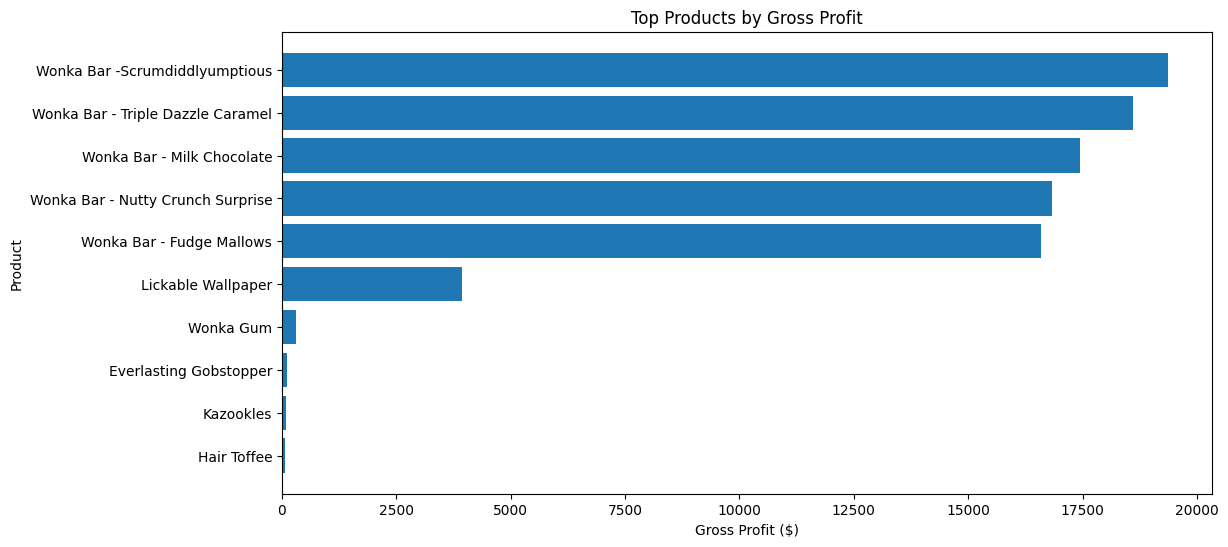

In [41]:
# Visualization
import matplotlib.pyplot as plt

top10 = gross_profit_rank.head(10)

plt.figure(figsize=(12,6))

plt.barh(top10.index, top10['Total_Gross_Profit'])

plt.xlabel("Gross Profit ($)")
plt.ylabel("Product")

plt.title("Top Products by Gross Profit")

plt.gca().invert_yaxis()

plt.show()

In [42]:
#### Rank Products by Gross Margin
gross_margin_rank = product_summary.sort_values(
    by ='Average_Gross_Margin',
    ascending=False
)
gross_margin_rank
gross_margin_rank.head(10)

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00
Hair Toffee,76.50,17.00,59.50,17,77.78,3.50
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,71.35,2.49
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,69.44,2.50
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,66.67,2.40
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,65.33,2.45
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,64.92,2.11
Laffy Taffy,53.73,20.25,33.48,27,62.31,1.24
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,2.25


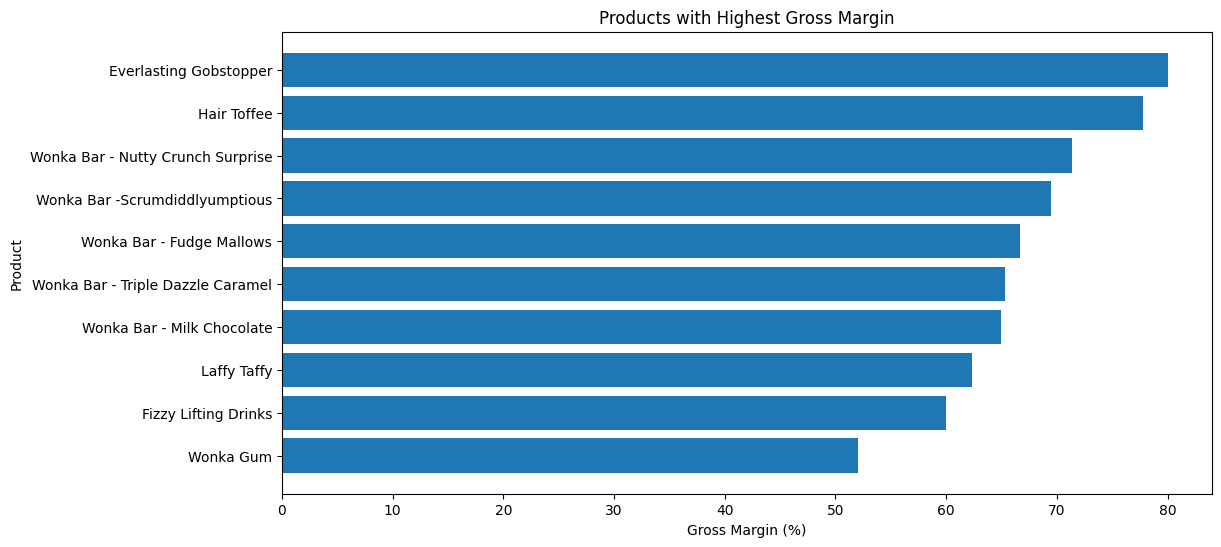

In [43]:
#  Visualization – Gross Margin Ranking
top_margin = gross_margin_rank.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_margin.index,
         top_margin['Average_Gross_Margin'])

plt.xlabel("Gross Margin (%)")

plt.ylabel("Product")

plt.title("Products with Highest Gross Margin")

plt.gca().invert_yaxis()

plt.show()

In [44]:
### Identify High-Profit / High-Margin Products
avg_profit = product_summary['Total_Gross_Profit'].mean()
avg_margin = product_summary['Average_Gross_Margin'].mean()
high_profit_high_margin = product_summary[
    (product_summary['Total_Gross_Profit'] > avg_profit) &
    (product_summary['Average_Gross_Margin'] > avg_margin)
]
high_profit_high_margin

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60,6914,66.67,2.40
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,8267,64.92,2.11
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95,6755,71.35,2.49
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20,7596,65.33,2.45
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,69.44,2.50


In [45]:
### Identify High-Sales / Low-Margin Products

avg_sales = product_summary['Total_sales'].mean()
avg_margin = product_summary['Average_Gross_Margin'].mean()
high_sales_low_margin = product_summary[
    (product_summary['Total_sales'] > avg_sales) &
    (product_summary['Average_Gross_Margin'] < avg_margin)
]

high_sales_low_margin

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,


In [47]:
#### Identify Low-Sales / Low-Profit Products
avg_sales = product_summary['Total_sales'].mean()

avg_profit = product_summary['Total_Gross_Profit'].mean()

low_sales_low_profit = product_summary[
    (product_summary['Total_sales'] < avg_sales) &
    (product_summary['Total_Gross_Profit'] < avg_profit)
]

low_sales_low_profit

,Total_sales,Total_cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,2.25
Fun Dip,12.00,7.20,4.80,8,40.00,0.60
Hair Toffee,76.50,17.00,59.50,17,77.78,3.50
Kazookles,1205.75,1113.00,92.75,371,7.69,0.25
Laffy Taffy,53.73,20.25,33.48,27,62.31,1.24
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,10.00
Nerds,15.00,8.00,7.00,10,46.67,0.70
Sweetarts,61.50,32.80,28.70,41,46.67,0.70


In [48]:
product_summary.to_csv(
    "Product_Level_Profitability.csv",
    index=True
)

**Division-Level Performance Analysis**

In [49]:
#### Aggregate Metrics by Division
division_summary = (
    df.groupby('division')
      .agg(
          Total_Sales=('sales', 'sum'),
          Total_Cost=('cost', 'sum'),
          Total_Gross_Profit=('gross_profit', 'sum'),
          Total_Units=('units', 'sum'),
          Average_Gross_Margin=('gross_margin_%', 'mean'),
          Average_Profit_Per_Unit=('profit_per_unit', 'mean')
      )
      .round(2)
      .sort_values(by='Total_Gross_Profit', ascending=False)
)

division_summary

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit
division,,,,,,
Chocolate,131692.90,42868.28,88824.62,37275,67.46,2.38
Other,9663.25,5329.80,4333.45,1242,37.67,3.36
Sugar,427.48,142.75,284.73,137,57.69,1.89


In [50]:
### Calculate Profit Contribution by Division
total_profit = division_summary['Total_Gross_Profit'].sum()

division_summary['Profit_Contribution_%'] = (
    division_summary['Total_Gross_Profit']
    / total_profit
) * 100

division_summary = division_summary.round(2)

division_summary

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit,Profit_Contribution_%
division,,,,,,,
Chocolate,131692.90,42868.28,88824.62,37275,67.46,2.38,95.06
Other,9663.25,5329.80,4333.45,1242,37.67,3.36,4.64
Sugar,427.48,142.75,284.73,137,57.69,1.89,0.30


In [51]:
#### Rank Divisions by Gross Profit
division_summary.sort_values(by='Total_Gross_Profit', ascending=False)

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit,Profit_Contribution_%
division,,,,,,,
Chocolate,131692.90,42868.28,88824.62,37275,67.46,2.38,95.06
Other,9663.25,5329.80,4333.45,1242,37.67,3.36,4.64
Sugar,427.48,142.75,284.73,137,57.69,1.89,0.30


In [52]:
### Rank Divisions by Gross Margin
division_summary.sort_values(
    by='Average_Gross_Margin',
    ascending=False
)

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit,Profit_Contribution_%
division,,,,,,,
Chocolate,131692.90,42868.28,88824.62,37275,67.46,2.38,95.06
Sugar,427.48,142.75,284.73,137,57.69,1.89,0.30
Other,9663.25,5329.80,4333.45,1242,37.67,3.36,4.64


In [53]:
### Revenue Vs Profit Comparision
division_summary[['Total_Sales',
                  'Total_Gross_Profit']]

,Total_Sales,Total_Gross_Profit
division,,
Chocolate,131692.90,88824.62
Other,9663.25,4333.45
Sugar,427.48,284.73


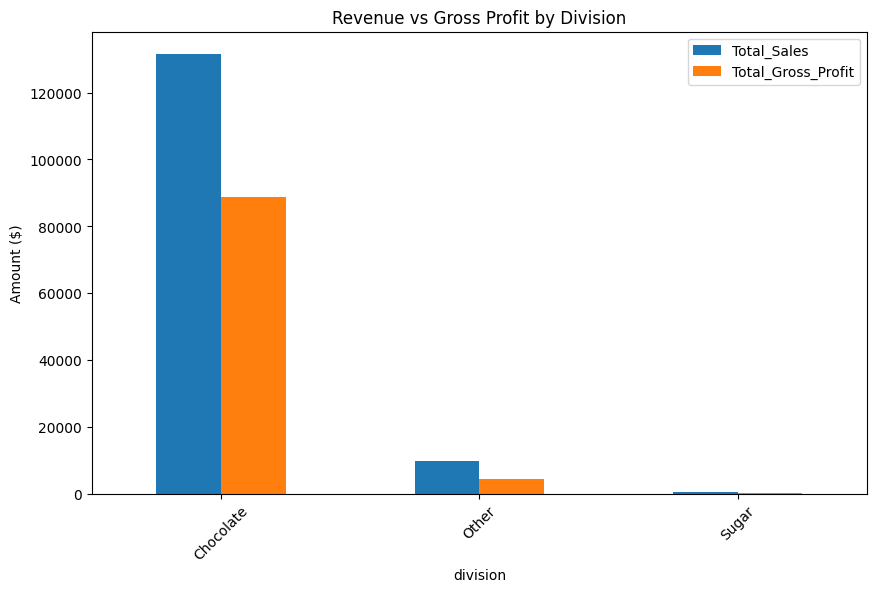

In [54]:
### Revenue vs Gross Profit
import matplotlib.pyplot as plt

division_summary[['Total_Sales',
                  'Total_Gross_Profit']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Revenue vs Gross Profit by Division")

plt.ylabel("Amount ($)")

plt.xticks(rotation=45)

plt.show()

In [55]:
### Average Gross Margin by Division
division_summary[['Average_Gross_Margin']]

,Average_Gross_Margin
division,
Chocolate,67.46
Other,37.67
Sugar,57.69


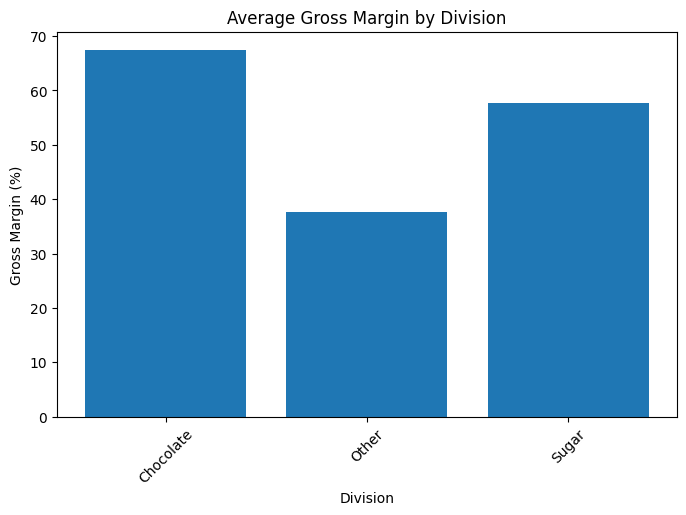

In [56]:
# average gross margin
plt.figure(figsize=(8,5))

plt.bar(
    division_summary.index,
    division_summary['Average_Gross_Margin']
)

plt.ylabel("Gross Margin (%)")

plt.xlabel("Division")

plt.title("Average Gross Margin by Division")

plt.xticks(rotation=45)

plt.show()

In [57]:
### Identify Strong Financial efficiency
avg_profit = division_summary['Total_Gross_Profit'].mean()
avg_margin = division_summary['Average_Gross_Margin'].mean()

efficient_divisions = division_summary[
    (division_summary['Total_Gross_Profit']> avg_profit)
& (division_summary['Average_Gross_Margin'] > avg_margin)
]

efficient_divisions

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit,Profit_Contribution_%
division,,,,,,,
Chocolate,131692.9,42868.28,88824.62,37275,67.46,2.38,95.06


In [58]:
### Identify Structural Margin Issues
avg_sales = division_summary['Total_Sales'].mean()

avg_margin = division_summary['Average_Gross_Margin'].mean()

margin_issue = division_summary[
    (division_summary['Total_Sales'] > avg_sales) &
    (division_summary['Average_Gross_Margin'] < avg_margin)
]

margin_issue

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Average_Profit_Per_Unit,Profit_Contribution_%
division,,,,,,,


In [59]:
division_summary.to_csv(
    "Division_Performance_Analysis.csv"
)

**Profit Concentration (Pareto) Analysis**

In [60]:
### Part A: 80% Revenue Analysis
#Step 1: Product-wise  Revenue
revenue_pareto = (
    df.groupby('product_name')
      .agg(Total_Revenue=('sales', 'sum'))
      .sort_values(by='Total_Revenue', ascending=False)
)

revenue_pareto

,Total_Revenue
product_name,
Wonka Bar - Triple Dazzle Caramel,28485.00
Wonka Bar -Scrumdiddlyumptious,27874.80
Wonka Bar - Milk Chocolate,26867.75
Wonka Bar - Fudge Mallows,24890.40
Wonka Bar - Nutty Crunch Surprise,23574.95
Lickable Wallpaper,7860.00
Kazookles,1205.75
Wonka Gum,597.50
Everlasting Gobstopper,130.00


In [61]:
### Step 2: Revenue Contribution %
total_revenue = revenue_pareto['Total_Revenue'].sum()

revenue_pareto['Revenue_%'] = (
    revenue_pareto['Total_Revenue']
    / total_revenue
) * 100

revenue_pareto = revenue_pareto.round(2)

In [62]:
### Step 3: Cumulative Revenue %
revenue_pareto['Cumulative_Revenue_%'] = (
    revenue_pareto['Revenue_%']
    .cumsum()
)

revenue_pareto

,Total_Revenue,Revenue_%,Cumulative_Revenue_%
product_name,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,20.09,20.09
Wonka Bar -Scrumdiddlyumptious,27874.80,19.66,39.75
Wonka Bar - Milk Chocolate,26867.75,18.95,58.70
Wonka Bar - Fudge Mallows,24890.40,17.56,76.26
Wonka Bar - Nutty Crunch Surprise,23574.95,16.63,92.89
Lickable Wallpaper,7860.00,5.54,98.43
Kazookles,1205.75,0.85,99.28
Wonka Gum,597.50,0.42,99.70
Everlasting Gobstopper,130.00,0.09,99.79


In [63]:
### step 4: Products Generating 80% Revenue
top80_revenue = revenue_pareto[
    revenue_pareto['Cumulative_Revenue_%'] <= 80
]

top80_revenue

,Total_Revenue,Revenue_%,Cumulative_Revenue_%
product_name,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,20.09,20.09
Wonka Bar -Scrumdiddlyumptious,27874.80,19.66,39.75
Wonka Bar - Milk Chocolate,26867.75,18.95,58.70
Wonka Bar - Fudge Mallows,24890.40,17.56,76.26


In [64]:
### Step 5: Percentage of Products
products_80_revenue = len(top80_revenue)

total_products = revenue_pareto.shape[0]

percentage_products = (
    products_80_revenue
    / total_products
) * 100

print("Products contributing 80% Revenue:",
      products_80_revenue)

print("Percentage of Products:",
      round(percentage_products,2),"%")

Products contributing 80% Revenue: 4
Percentage of Products: 26.67 %


In [65]:
### Part B: 80% Profit Analysis
profit_pareto = (
    df.groupby('product_name')
      .agg(
          Total_Profit=('gross_profit','sum')
      )
      .sort_values(by='Total_Profit',
                   ascending=False)
)

In [66]:
total_profit = profit_pareto['Total_Profit'].sum()
profit_pareto['Profit_%'] = (
    profit_pareto['Total_Profit']
    / total_profit
) * 100

In [67]:
profit_pareto['Cumulative_Profit_%'] = (
    profit_pareto['Profit_%']
    .cumsum()
)

profit_pareto

,Total_Profit,Profit_%,Cumulative_Profit_%
product_name,,,
Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882,20.715882
Wonka Bar - Triple Dazzle Caramel,18610.20,19.916141,40.632023
Wonka Bar - Milk Chocolate,17443.37,18.667431,59.299454
Wonka Bar - Nutty Crunch Surprise,16819.95,18.000263,77.299717
Wonka Bar - Fudge Mallows,16593.60,17.758030,95.057747
Lickable Wallpaper,3930.00,4.205782,99.263528
Wonka Gum,310.70,0.332503,99.596031
Everlasting Gobstopper,104.00,0.111298,99.707329
Kazookles,92.75,0.099259,99.806588


In [68]:
top80_profit = profit_pareto[
    profit_pareto['Cumulative_Profit_%'] <= 80
]

top80_profit

,Total_Profit,Profit_%,Cumulative_Profit_%
product_name,,,
Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882,20.715882
Wonka Bar - Triple Dazzle Caramel,18610.20,19.916141,40.632023
Wonka Bar - Milk Chocolate,17443.37,18.667431,59.299454
Wonka Bar - Nutty Crunch Surprise,16819.95,18.000263,77.299717


In [69]:
products_80_profit = len(top80_profit)

percentage_products = (
    products_80_profit
    / len(profit_pareto)
) * 100

print("Products contributing 80% Profit:",
      products_80_profit)

print("Percentage of Products:",
      round(percentage_products,2),"%")

Products contributing 80% Profit: 4
Percentage of Products: 26.67 %


In [70]:
# • Detect congestion-prone states or regionIdentify over-dependency risks
# step 1:Region-wise Performance

region_summary = (
    df.groupby('region')
      .agg(
          Total_Sales=('sales','sum'),
          Total_Gross_Profit=('gross_profit','sum'),
          Total_Units=('units','sum')
      )
      .round(2)
      .sort_values(by='Total_Sales', ascending=False)
)

region_summary



,Total_Sales,Total_Gross_Profit,Total_Units
region,,,
Pacific,46301.53,30485.94,12466
Atlantic,41197.24,26973.70,11159
Interior,32037.60,21282.49,8820
Gulf,22247.26,14700.67,6209


In [71]:
# step 2:Revenue Contribution by Region
region_summary['Revenue_Contribution_%'] = (
    region_summary['Total_Sales']
    / region_summary['Total_Sales'].sum()
) * 100

region_summary = region_summary.round(2)

region_summary


,Total_Sales,Total_Gross_Profit,Total_Units,Revenue_Contribution_%
region,,,,
Pacific,46301.53,30485.94,12466,32.66
Atlantic,41197.24,26973.70,11159,29.06
Interior,32037.60,21282.49,8820,22.60
Gulf,22247.26,14700.67,6209,15.69


In [72]:
# step 3: Profit Contribution by Region
region_summary['Profit_Contribution_%'] = (
    region_summary['Total_Gross_Profit']
    / region_summary['Total_Gross_Profit'].sum()
) * 100

region_summary

,Total_Sales,Total_Gross_Profit,Total_Units,Revenue_Contribution_%,Profit_Contribution_%
region,,,,,
Pacific,46301.53,30485.94,12466,32.66,32.625242
Atlantic,41197.24,26973.70,11159,29.06,28.866537
Interior,32037.60,21282.49,8820,22.60,22.775955
Gulf,22247.26,14700.67,6209,15.69,15.732266


In [73]:
# Step 4: State-wise Performance

state_summary = (
    df.groupby('state/province')
      .agg(
          Total_Sales=('sales','sum'),
          Total_Gross_Profit=('gross_profit','sum')
      )
      .round(2)
      .sort_values(by='Total_Sales', ascending=False)
)

state_summary.head(10)

,Total_Sales,Total_Gross_Profit
state/province,,
California,27917.40,18479.42
New York,15541.03,10222.44
Texas,13416.09,8909.53
Pennsylvania,8027.03,5225.47
Washington,6921.15,4566.64
Illinois,6898.96,4557.68
Ohio,6768.95,4413.03
Florida,4804.02,3207.11
Arizona,3587.55,2290.11


In [74]:
# Step 5: State Revenue Contribution
state_summary['Revenue_Contribution_%'] = (
    state_summary['Total_Sales']
    / state_summary['Total_Sales'].sum()
) * 100

state_summary = state_summary.round(2)

state_summary.head(10)

,Total_Sales,Total_Gross_Profit,Revenue_Contribution_%
state/province,,,
California,27917.40,18479.42,19.69
New York,15541.03,10222.44,10.96
Texas,13416.09,8909.53,9.46
Pennsylvania,8027.03,5225.47,5.66
Washington,6921.15,4566.64,4.88
Illinois,6898.96,4557.68,4.87
Ohio,6768.95,4413.03,4.77
Florida,4804.02,3207.11,3.39
Arizona,3587.55,2290.11,2.53


In [75]:
# Step 6: Detect Over-Dependency Risk (Regions)
high_dependency_regions = region_summary[
    region_summary['Revenue_Contribution_%'] > 25
]

high_dependency_regions

,Total_Sales,Total_Gross_Profit,Total_Units,Revenue_Contribution_%,Profit_Contribution_%
region,,,,,
Pacific,46301.53,30485.94,12466,32.66,32.625242
Atlantic,41197.24,26973.70,11159,29.06,28.866537


In [76]:
# Step 7: Detect Over-Dependency Risk (States)
high_dependency_states = state_summary[
    state_summary['Revenue_Contribution_%'] > 10
]

high_dependency_states

,Total_Sales,Total_Gross_Profit,Revenue_Contribution_%
state/province,,,
California,27917.40,18479.42,19.69
New York,15541.03,10222.44,10.96


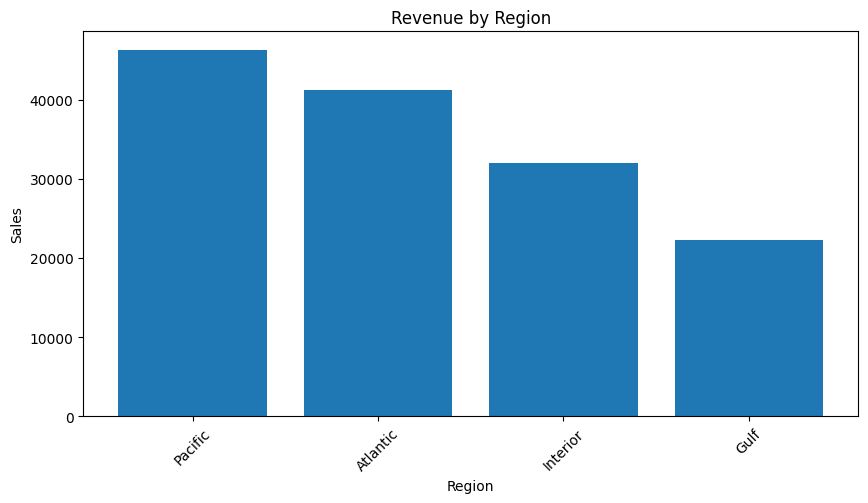

In [77]:
# Visualization 1: Revenue by Region
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(region_summary.index,
        region_summary['Total_Sales'])

plt.title("Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

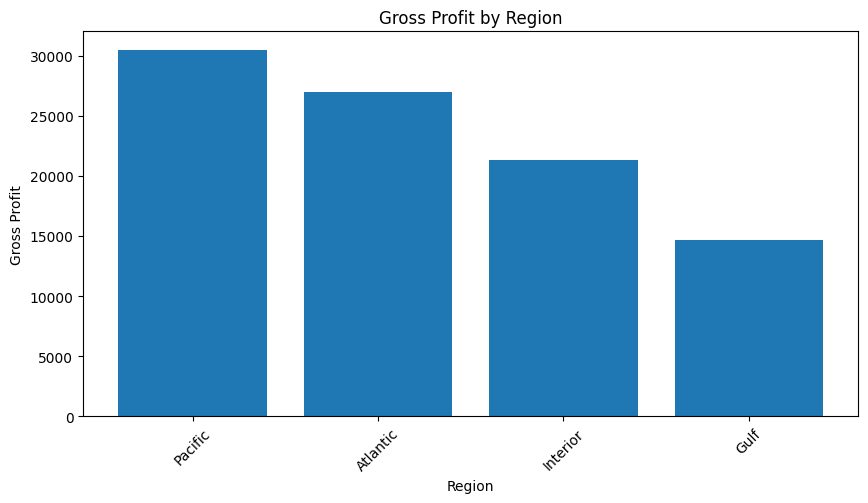

In [78]:
# Visualization 2: Profit by Region
plt.figure(figsize=(10,5))

plt.bar(region_summary.index,
        region_summary['Total_Gross_Profit'])

plt.title("Gross Profit by Region")

plt.xlabel("Region")

plt.ylabel("Gross Profit")

plt.xticks(rotation=45)

plt.show()

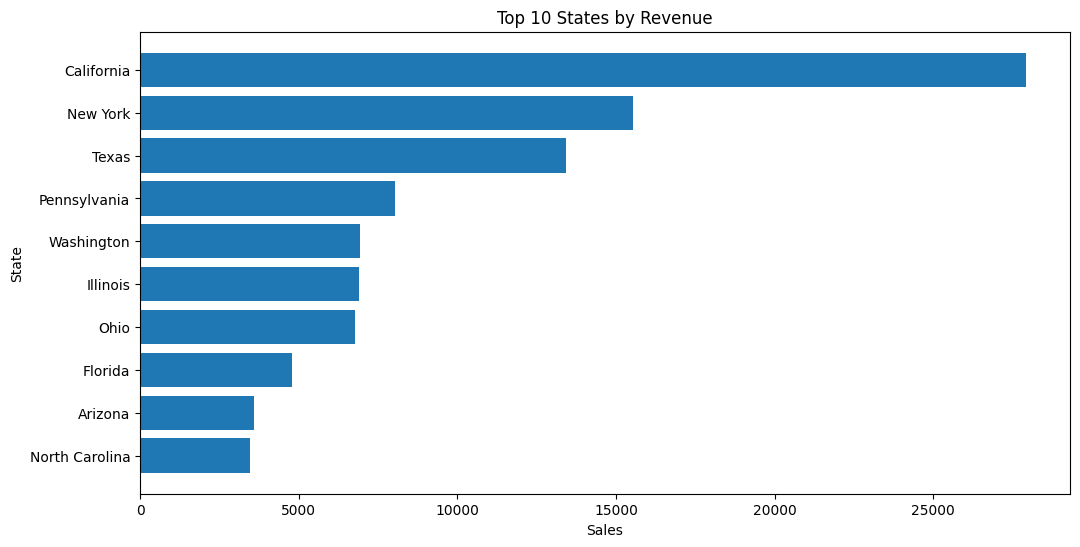

In [79]:
# Visualization 3: Top 10 States
top_states = state_summary.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_states.index,
         top_states['Total_Sales'])

plt.xlabel("Sales")

plt.ylabel("State")

plt.title("Top 10 States by Revenue")

plt.gca().invert_yaxis()

plt.show()

**Cost Structure Diagnostics**

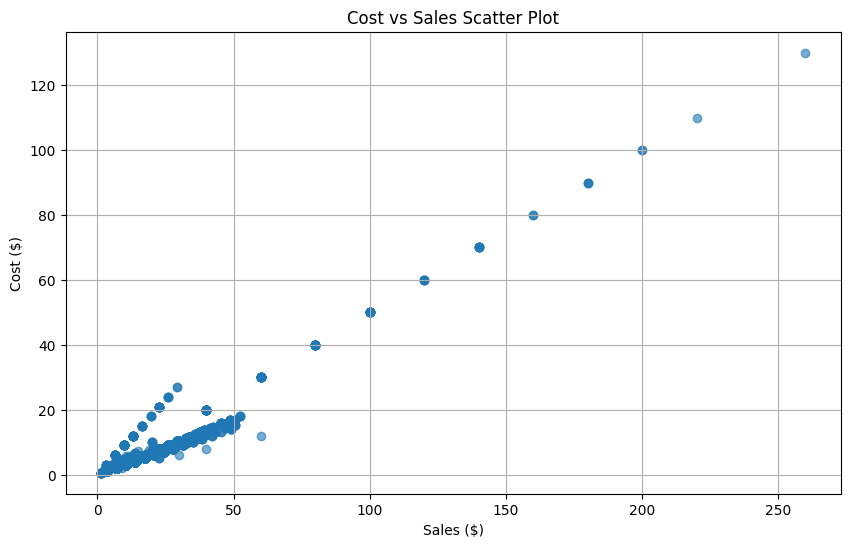

In [80]:
# Step 1: Create Scatter Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['sales'],
    df['cost'],
    alpha=0.6
)

plt.xlabel("Sales ($)")
plt.ylabel("Cost ($)")
plt.title("Cost vs Sales Scatter Plot")

plt.grid(True)

plt.show()

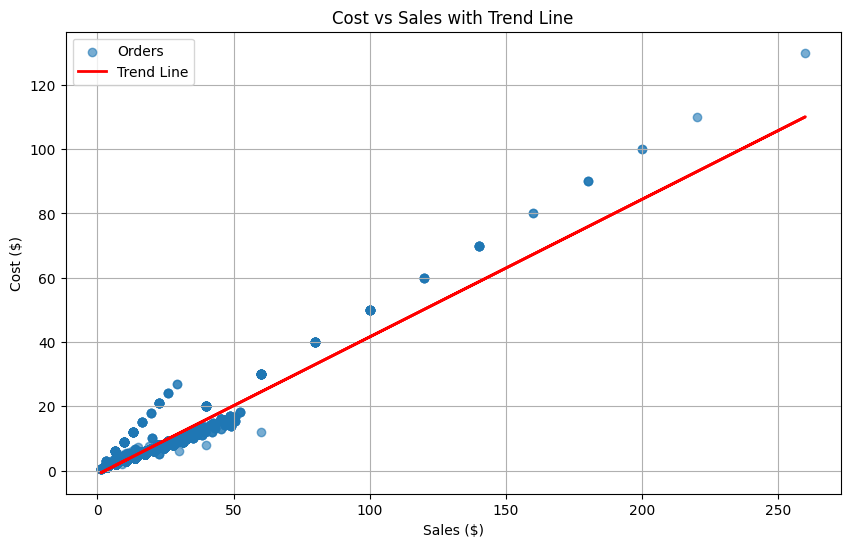

In [81]:
# Step 2: Add a Trend Line
import numpy as np

plt.figure(figsize=(10,6))

plt.scatter(
    df['sales'],
    df['cost'],
    alpha=0.6,
    label='Orders'
)

# Trend line
z = np.polyfit(df['sales'], df['cost'], 1)
p = np.poly1d(z)

plt.plot(
    df['sales'],
    p(df['sales']),
    color='red',
    linewidth=2,
    label='Trend Line'
)

plt.xlabel("Sales ($)")
plt.ylabel("Cost ($)")
plt.title("Cost vs Sales with Trend Line")

plt.legend()

plt.grid(True)

plt.show()

In [82]:
# Step 3: Calculate Correlation
correlation = df[['sales','cost']].corr()

print(correlation)

          sales      cost
sales  1.000000  0.958986
cost   0.958986  1.000000


In [83]:
# Step 4: Identify High-Cost Products
high_cost = (
    df.groupby('product_name')
      .agg(
          Total_Sales=('sales','sum'),
          Total_Cost=('cost','sum'),
          Total_Gross_Profit=('gross_profit','sum')
      )
      .sort_values(by='Total_Cost', ascending=False)
)

high_cost.head(10)

,Total_Sales,Total_Cost,Total_Gross_Profit
product_name,,,
Wonka Bar - Triple Dazzle Caramel,28485.00,9874.80,18610.20
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37
Wonka Bar -Scrumdiddlyumptious,27874.80,8517.30,19357.50
Wonka Bar - Fudge Mallows,24890.40,8296.80,16593.60
Wonka Bar - Nutty Crunch Surprise,23574.95,6755.00,16819.95
Lickable Wallpaper,7860.00,3930.00,3930.00
Kazookles,1205.75,1113.00,92.75
Wonka Gum,597.50,286.80,310.70
Sweetarts,61.50,32.80,28.70


In [84]:
# Step 5: Cost-to-Sales Ratio
df['cost_to_sales_ratio'] = (
    df['cost'] / df['sales']
).round(2)

df[['product_name',
    'sales',
    'cost',
    'cost_to_sales_ratio']].head()

,product_name,sales,cost,cost_to_sales_ratio
0,Wonka Bar - Milk Chocolate,6.50,2.28,0.35
1,Wonka Bar - Triple Dazzle Caramel,7.50,2.60,0.35
2,Wonka Bar - Nutty Crunch Surprise,10.47,3.00,0.29
3,Wonka Bar -Scrumdiddlyumptious,10.80,3.30,0.31
4,Wonka Bar - Triple Dazzle Caramel,11.25,3.90,0.35


In [85]:
# Step 6: Average Cost-to-Sales Ratio by Product
cost_ratio = (
    df.groupby('product_name')
      .agg(
          Average_Cost_Ratio=('cost_to_sales_ratio','mean')
      )
      .round(2)
      .sort_values(by='Average_Cost_Ratio',
                   ascending=False)
)

cost_ratio

,Average_Cost_Ratio
product_name,
Kazookles,0.92
Fun Dip,0.60
Nerds,0.53
Sweetarts,0.53
Lickable Wallpaper,0.50
Wonka Gum,0.48
Fizzy Lifting Drinks,0.40
Laffy Taffy,0.38
Wonka Bar - Milk Chocolate,0.35


In [86]:
print("Correlation:", round(df['sales'].corr(df['cost']), 3))

Correlation: 0.959


In [87]:
#### • Identify:
#○ Cost-heavy, margin-poor products
### Step 1: Create Product Cost Summary
product_cost_analysis = (
    df.groupby('product_name')
      .agg(
          Total_Sales=('sales', 'sum'),
          Total_Cost=('cost', 'sum'),
          Total_Gross_Profit=('gross_profit', 'sum'),
          Average_Gross_Margin=('gross_margin_%', 'mean')
      )
      .round(2)
)

product_cost_analysis


,Total_Sales,Total_Cost,Total_Gross_Profit,Average_Gross_Margin
product_name,,,,
Everlasting Gobstopper,130.00,26.00,104.00,80.00
Fizzy Lifting Drinks,78.75,31.50,47.25,60.00
Fun Dip,12.00,7.20,4.80,40.00
Hair Toffee,76.50,17.00,59.50,77.78
Kazookles,1205.75,1113.00,92.75,7.69
Laffy Taffy,53.73,20.25,33.48,62.31
Lickable Wallpaper,7860.00,3930.00,3930.00,50.00
Nerds,15.00,8.00,7.00,46.67
Sweetarts,61.50,32.80,28.70,46.67


In [88]:
# Step 2: Calculate Cost-to-Sales Ratio
product_cost_analysis['Cost_to_Sales_%'] = (
    product_cost_analysis['Total_Cost']
    / product_cost_analysis['Total_Sales']
) * 100

product_cost_analysis = product_cost_analysis.round(2)

product_cost_analysis

,Total_Sales,Total_Cost,Total_Gross_Profit,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,80.00,20.00
Fizzy Lifting Drinks,78.75,31.50,47.25,60.00,40.00
Fun Dip,12.00,7.20,4.80,40.00,60.00
Hair Toffee,76.50,17.00,59.50,77.78,22.22
Kazookles,1205.75,1113.00,92.75,7.69,92.31
Laffy Taffy,53.73,20.25,33.48,62.31,37.69
Lickable Wallpaper,7860.00,3930.00,3930.00,50.00,50.00
Nerds,15.00,8.00,7.00,46.67,53.33
Sweetarts,61.50,32.80,28.70,46.67,53.33


In [90]:
### Step 3: Identify Cost-Heavy Products
cost_heavy_products = (
    product_cost_analysis
    .sort_values(
        by='Cost_to_Sales_%',
        ascending=False
    )
)

cost_heavy_products

,Total_Sales,Total_Cost,Total_Gross_Profit,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,
Kazookles,1205.75,1113.00,92.75,7.69,92.31
Fun Dip,12.00,7.20,4.80,40.00,60.00
Nerds,15.00,8.00,7.00,46.67,53.33
Sweetarts,61.50,32.80,28.70,46.67,53.33
Lickable Wallpaper,7860.00,3930.00,3930.00,50.00,50.00
Wonka Gum,597.50,286.80,310.70,52.00,48.00
Fizzy Lifting Drinks,78.75,31.50,47.25,60.00,40.00
Laffy Taffy,53.73,20.25,33.48,62.31,37.69
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,64.92,35.08


In [91]:
# Step 4: Identify Margin-Poor Products
margin_poor_products = (
    product_cost_analysis
    .sort_values(
        by='Average_Gross_Margin',
        ascending=True
    )
)

margin_poor_products
margin_poor_products.head(10)

,Total_Sales,Total_Cost,Total_Gross_Profit,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,
Kazookles,1205.75,1113.00,92.75,7.69,92.31
Fun Dip,12.00,7.20,4.80,40.00,60.00
Nerds,15.00,8.00,7.00,46.67,53.33
Sweetarts,61.50,32.80,28.70,46.67,53.33
Lickable Wallpaper,7860.00,3930.00,3930.00,50.00,50.00
Wonka Gum,597.50,286.80,310.70,52.00,48.00
Fizzy Lifting Drinks,78.75,31.50,47.25,60.00,40.00
Laffy Taffy,53.73,20.25,33.48,62.31,37.69
Wonka Bar - Milk Chocolate,26867.75,9424.38,17443.37,64.92,35.08


In [92]:
# Step 5: Identify Cost-Heavy & Margin-Poor Products
avg_cost_ratio = (
    product_cost_analysis['Cost_to_Sales_%']
    .mean()
)

avg_margin = (
    product_cost_analysis['Average_Gross_Margin']
    .mean()
)

cost_heavy_margin_poor = product_cost_analysis[
    (product_cost_analysis['Cost_to_Sales_%'] > avg_cost_ratio) &
    (product_cost_analysis['Average_Gross_Margin'] < avg_margin)
]

cost_heavy_margin_poor

,Total_Sales,Total_Cost,Total_Gross_Profit,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,
Fun Dip,12.00,7.2,4.80,40.00,60.00
Kazookles,1205.75,1113.0,92.75,7.69,92.31
Lickable Wallpaper,7860.00,3930.0,3930.00,50.00,50.00
Nerds,15.00,8.0,7.00,46.67,53.33
Sweetarts,61.50,32.8,28.70,46.67,53.33
Wonka Gum,597.50,286.8,310.70,52.00,48.00


In [93]:
# Step 6: Identify Pricing Inefficiencies
pricing_analysis = (
    df.groupby('product_name')
      .agg(
          Total_Sales=('sales','sum'),
          Total_Cost=('cost','sum'),
          Total_Units=('units','sum')
      )
)

pricing_analysis['Selling_Price_Per_Unit'] = (
    pricing_analysis['Total_Sales']
    / pricing_analysis['Total_Units']
)

pricing_analysis['Cost_Per_Unit'] = (
    pricing_analysis['Total_Cost']
    / pricing_analysis['Total_Units']
)

pricing_analysis['Profit_Per_Unit'] = (
    pricing_analysis['Selling_Price_Per_Unit']
    - pricing_analysis['Cost_Per_Unit']
)

pricing_analysis = pricing_analysis.round(2)

pricing_analysis

,Total_Sales,Total_Cost,Total_Units,Selling_Price_Per_Unit,Cost_Per_Unit,Profit_Per_Unit
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,13,10.00,2.00,8.00
Fizzy Lifting Drinks,78.75,31.50,21,3.75,1.50,2.25
Fun Dip,12.00,7.20,8,1.50,0.90,0.60
Hair Toffee,76.50,17.00,17,4.50,1.00,3.50
Kazookles,1205.75,1113.00,371,3.25,3.00,0.25
Laffy Taffy,53.73,20.25,27,1.99,0.75,1.24
Lickable Wallpaper,7860.00,3930.00,393,20.00,10.00,10.00
Nerds,15.00,8.00,10,1.50,0.80,0.70
Sweetarts,61.50,32.80,41,1.50,0.80,0.70


In [94]:
# Step 7: Rank Pricing Efficiency
pricing_analysis.sort_values(
    by='Profit_Per_Unit',
    ascending=True
)

,Total_Sales,Total_Cost,Total_Units,Selling_Price_Per_Unit,Cost_Per_Unit,Profit_Per_Unit
product_name,,,,,,
Kazookles,1205.75,1113.00,371,3.25,3.00,0.25
Fun Dip,12.00,7.20,8,1.50,0.90,0.60
Wonka Gum,597.50,286.80,478,1.25,0.60,0.65
Nerds,15.00,8.00,10,1.50,0.80,0.70
Sweetarts,61.50,32.80,41,1.50,0.80,0.70
Laffy Taffy,53.73,20.25,27,1.99,0.75,1.24
Wonka Bar - Milk Chocolate,26867.75,9424.38,8267,3.25,1.14,2.11
Fizzy Lifting Drinks,78.75,31.50,21,3.75,1.50,2.25
Wonka Bar - Fudge Mallows,24890.40,8296.80,6914,3.60,1.20,2.40


In [95]:
# Step 8: Export Results
product_cost_analysis.to_csv(
    "Cost_Efficiency_Analysis.csv"
)

pricing_analysis.to_csv(
    "Pricing_Analysis.csv"
)

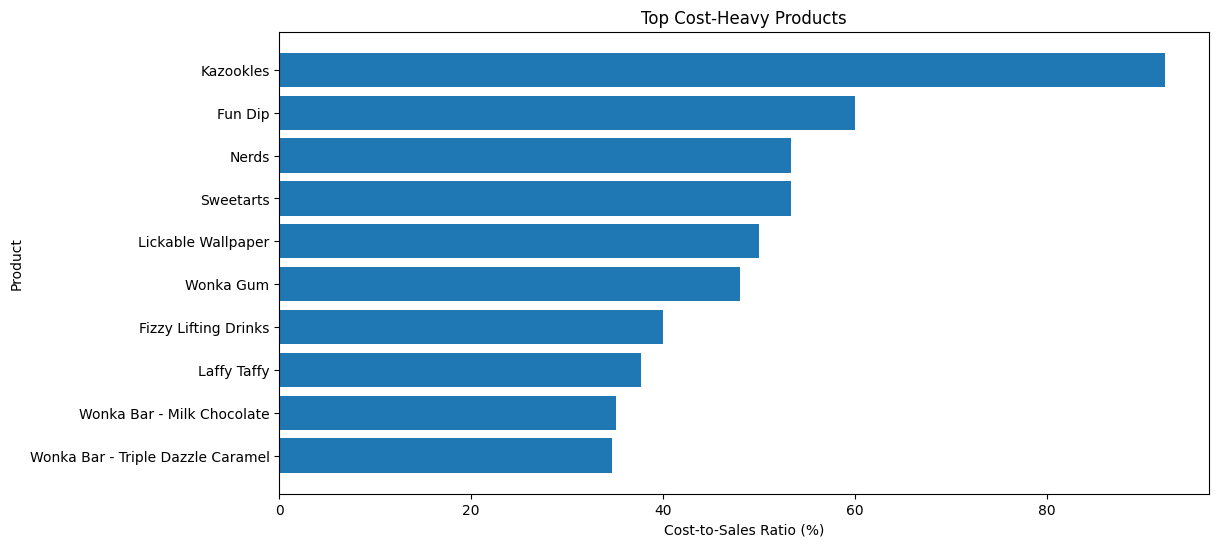

In [96]:
### 1. Cost-to-Sales Ratio by Product (visualization)
import matplotlib.pyplot as plt

# Re-defining cost_heavy_products for robustness
cost_heavy_products = (
    product_cost_analysis
    .sort_values(
        by='Cost_to_Sales_%',
        ascending=False
    )
)

top_cost = cost_heavy_products.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top_cost.index,
    top_cost['Cost_to_Sales_%']
)

plt.xlabel("Cost-to-Sales Ratio (%)")

plt.ylabel("Product")

plt.title("Top Cost-Heavy Products")

plt.gca().invert_yaxis()

plt.show()

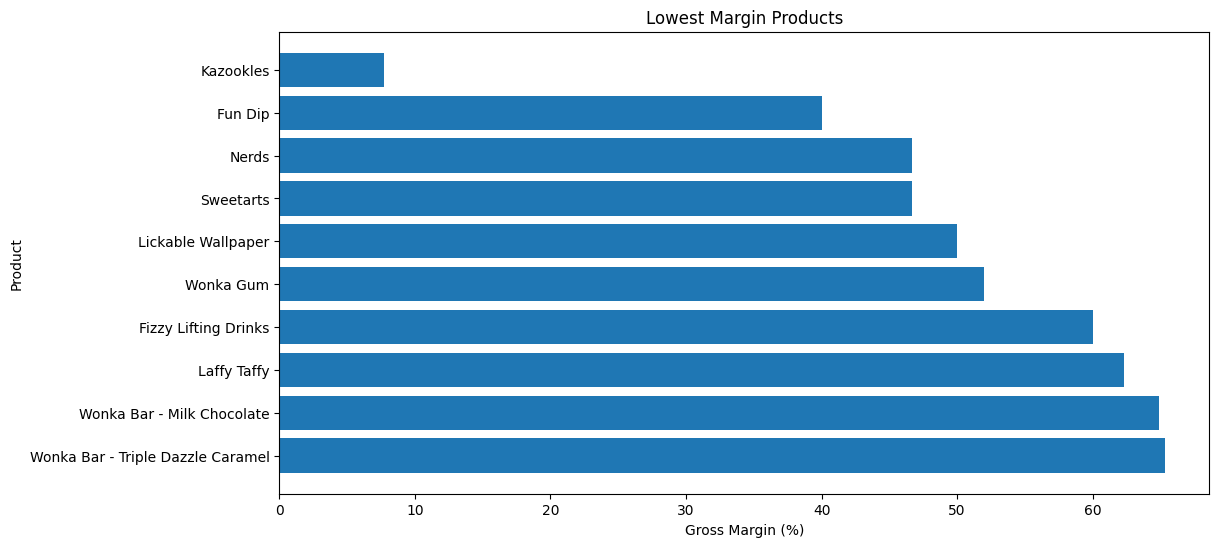

In [97]:
# 2. Gross Margin by Product
lowest_margin = margin_poor_products.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    lowest_margin.index,
    lowest_margin['Average_Gross_Margin']
)

plt.xlabel("Gross Margin (%)")

plt.ylabel("Product")

plt.title("Lowest Margin Products")

plt.gca().invert_yaxis()

plt.show()

####• Flag products needing:
- Repricing
- Cost renegotiation
- Discontinuation review

In [98]:
### Step 1: Create Product Decision Table
decision_df = (
    df.groupby('product_name')
      .agg(
          Total_Sales=('sales','sum'),
          Total_Cost=('cost','sum'),
          Total_Gross_Profit=('gross_profit','sum'),
          Total_Units=('units','sum'),
          Average_Gross_Margin=('gross_margin_%','mean')
      )
      .round(2)
)

In [99]:
### Step 2: Calculate Cost-to-Sales Ratio
decision_df['Cost_to_Sales_%'] = (
    decision_df['Total_Cost']
    / decision_df['Total_Sales']
) * 100

decision_df = decision_df.round(2)

decision_df

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,20.00
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,40.00
Fun Dip,12.00,7.20,4.80,8,40.00,60.00
Hair Toffee,76.50,17.00,59.50,17,77.78,22.22
Kazookles,1205.75,1113.00,92.75,371,7.69,92.31
Laffy Taffy,53.73,20.25,33.48,27,62.31,37.69
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,50.00
Nerds,15.00,8.00,7.00,10,46.67,53.33
Sweetarts,61.50,32.80,28.70,41,46.67,53.33


In [100]:
# Step 3: Calculate Company Averages
avg_sales = decision_df['Total_Sales'].mean()

avg_profit = decision_df['Total_Gross_Profit'].mean()

avg_margin = decision_df['Average_Gross_Margin'].mean()

avg_cost_ratio = decision_df['Cost_to_Sales_%'].mean()

In [101]:
# Step 4: Flag Products Needing Repricing
repricing = decision_df[
    (decision_df['Average_Gross_Margin'] < avg_margin) &
    (decision_df['Total_Sales'] > avg_sales)
]

repricing

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,,


In [102]:
# Step 5: Flag Products for Cost Renegotiation
cost_renegotiation = decision_df[
    decision_df['Cost_to_Sales_%'] > avg_cost_ratio
]

cost_renegotiation

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,,
Fun Dip,12.00,7.2,4.80,8,40.00,60.00
Kazookles,1205.75,1113.0,92.75,371,7.69,92.31
Lickable Wallpaper,7860.00,3930.0,3930.00,393,50.00,50.00
Nerds,15.00,8.0,7.00,10,46.67,53.33
Sweetarts,61.50,32.8,28.70,41,46.67,53.33
Wonka Gum,597.50,286.8,310.70,478,52.00,48.00


In [103]:
# Step 6: Flag Products for Discontinuation Review
discontinue_review = decision_df[
    (decision_df['Total_Sales'] < avg_sales) &
    (decision_df['Total_Gross_Profit'] < avg_profit)
]

discontinue_review

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Cost_to_Sales_%
product_name,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,20.00
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,40.00
Fun Dip,12.00,7.20,4.80,8,40.00,60.00
Hair Toffee,76.50,17.00,59.50,17,77.78,22.22
Kazookles,1205.75,1113.00,92.75,371,7.69,92.31
Laffy Taffy,53.73,20.25,33.48,27,62.31,37.69
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,50.00
Nerds,15.00,8.00,7.00,10,46.67,53.33
Sweetarts,61.50,32.80,28.70,41,46.67,53.33


In [104]:
# Step 7: Create a Final Recommendation Column
decision_df['Recommendation'] = 'Retain'

decision_df.loc[
    (decision_df['Average_Gross_Margin'] < avg_margin) &
    (decision_df['Total_Sales'] > avg_sales),
    'Recommendation'
] = 'Repricing'

decision_df.loc[
    decision_df['Cost_to_Sales_%'] > avg_cost_ratio,
    'Recommendation'
] = 'Cost Renegotiation'

decision_df.loc[
    (decision_df['Total_Sales'] < avg_sales) &
    (decision_df['Total_Gross_Profit'] < avg_profit),
    'Recommendation'
] = 'Discontinuation Review'

decision_df

,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Average_Gross_Margin,Cost_to_Sales_%,Recommendation
product_name,,,,,,,
Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,20.00,Discontinuation Review
Fizzy Lifting Drinks,78.75,31.50,47.25,21,60.00,40.00,Discontinuation Review
Fun Dip,12.00,7.20,4.80,8,40.00,60.00,Discontinuation Review
Hair Toffee,76.50,17.00,59.50,17,77.78,22.22,Discontinuation Review
Kazookles,1205.75,1113.00,92.75,371,7.69,92.31,Discontinuation Review
Laffy Taffy,53.73,20.25,33.48,27,62.31,37.69,Discontinuation Review
Lickable Wallpaper,7860.00,3930.00,3930.00,393,50.00,50.00,Discontinuation Review
Nerds,15.00,8.00,7.00,10,46.67,53.33,Discontinuation Review
Sweetarts,61.50,32.80,28.70,41,46.67,53.33,Discontinuation Review


In [105]:
# Step 8: Export Final Decision Table
decision_df.to_csv(
    "Strategic_Product_Recommendations.csv"
)

In [106]:
df.to_csv("Nassau_Candy_Cleaned.csv", index=False)

In [107]:
import pandas as pd

df = pd.read_csv("Nassau_Candy_Cleaned.csv")

print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'country/region', 'city', 'state/province', 'postal_code', 'division', 'region', 'product_id', 'product_name', 'sales', 'units', 'gross_profit', 'cost', 'gross_margin_%', 'profit_per_unit', 'cost_to_sales_ratio']
